# Урок 3. Дообучить маленькую модель или спросить LLM?

🎯 **Цели урока**

- дообучить rubert-tiny2 на 45 тысячах отзывов с помощью `Trainer` из Hugging Face;
- решить ту же задачу промптом к двум LLM курса: zero-shot, few-shot и с переформулированной задачей;
- получить ответ LLM в строгом формате через JSON-схему;
- сравнить подходы по качеству, скорости и стоимости и понять, когда какой выбирать.

📖 **Теория:** разделы «Экосистема Hugging Face» и «Дообучение или промпт».

⏱ Дообучение занимает ~10 минут на Mac M1, поэтому урок не выполняется в CI. Ответы LLM
(1500 запросов) записаны в кассеты `./cassettes`.

In [1]:
import collections
import json
import time
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")  # tqdm в Jupyter без ipywidgets
warnings.filterwarnings("ignore", message=".*pin_memory.*")  # MPS не поддерживает pinned memory

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
import torch  # noqa: E402
from datasets import Dataset, disable_progress_bars  # noqa: E402
from huggingface_hub.utils import logging as hub_logging  # noqa: E402
from sklearn.feature_extraction.text import TfidfVectorizer  # noqa: E402
from sklearn.linear_model import LogisticRegression  # noqa: E402
from sklearn.metrics import accuracy_score, confusion_matrix  # noqa: E402
from sklearn.pipeline import make_pipeline, make_union  # noqa: E402
from transformers import (  # noqa: E402
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)
from transformers.utils import logging as hf_logging  # noqa: E402

import mlcourse  # noqa: E402
from mlcourse import data_dir, fetch, get_client, get_device, model_name, no_thinking, seed_everything  # noqa: E402

hf_logging.set_verbosity_error()
hub_logging.set_verbosity_error()
disable_progress_bars()
seed_everything(0)
device = get_device()
print(mlcourse.describe_settings())

folder = fetch("rureviews")
train, val, test = (pd.read_json(folder / f"{s}.jsonl", lines=True) for s in ("train", "validation", "test"))
labels = ["negative", "neutral", "positive"]

main   qwen3.8-27b  https://<удалённый сервер>/v1
local  qwen3:8b     http://localhost:11434/v1
embed  bge-m3       http://localhost:11434/v1
кэш    record       LLM_CACHE


Все подходы сравним на одной и той же выборке — по 100 отзывов каждого класса из теста.
300 примеров — это погрешность около ±5 процентных пунктов. Разницу в 1–2 пункта на такой
выборке не увидеть, а в 5–10 — можно. Модели, которые дёшево применять ко всему тесту,
оценим и на всех 15 тысячах.

In [2]:
sample = test.groupby("label_text").sample(100, random_state=0).reset_index(drop=True)
results = {}


def record(name, preds_sample, seconds_per_1000=None, full_test_acc=None):
    results[name] = {"accuracy (300)": accuracy_score(sample.label_text, preds_sample),
                     "accuracy (весь тест)": full_test_acc, "секунд на 1000 отзывов": seconds_per_1000}
    print(f"{name:34} accuracy на 300: {results[name]['accuracy (300)']:.3f}")

## 1. Baseline: TF-IDF из урока 1

In [3]:
tfidf = make_pipeline(
    make_union(TfidfVectorizer(min_df=2, ngram_range=(1, 2)),
               TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=3, max_features=300_000)),
    LogisticRegression(max_iter=3000),
).fit(train.text, train.label_text)

start = time.perf_counter()
full_pred = tfidf.predict(test.text)
per_1000 = (time.perf_counter() - start) / len(test) * 1000
record("TF-IDF + логрегрессия", tfidf.predict(sample.text), per_1000, accuracy_score(test.label_text, full_pred))

TF-IDF + логрегрессия              accuracy на 300: 0.770


## 2. Дообучение rubert-tiny2

rubert-tiny2 — маленький BERT для русского (29 млн параметров, лицензия MIT). Добавим к нему голову
на три класса и дообучим целиком. `Trainer` берёт на себя цикл обучения из M03: батчи, устройство,
расписание LR, оценку по эпохам.

In [4]:
checkpoint = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint, num_labels=3, id2label=dict(enumerate(labels)), label2id={name: i for i, name in enumerate(labels)},
)


def to_dataset(frame):
    ds = Dataset.from_pandas(frame[["text", "label"]], preserve_index=False)
    return ds.map(lambda b: tokenizer(b["text"], truncation=True, max_length=128), batched=True,
                  remove_columns=["text"])


train_ds, val_ds = to_dataset(train), to_dataset(val)


def compute_metrics(eval_pred):
    logits, y = eval_pred
    return {"accuracy": accuracy_score(y, logits.argmax(axis=-1))}


args = TrainingArguments(
    output_dir=str(data_dir("checkpoints") / "rubert-tiny2-rureviews"),
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=256,
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_steps=0.1,  # дробь — доля шагов прогрева (в transformers 5 заменяет warmup_ratio)
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=500,
    report_to=[],
    disable_tqdm=True,
    dataloader_pin_memory=False,
    seed=0,
)
trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
                  data_collator=DataCollatorWithPadding(tokenizer), compute_metrics=compute_metrics)
start = time.perf_counter()
trainer.train()
print(f"обучение: {(time.perf_counter() - start) / 60:.1f} мин на {trainer.args.device}")

{'loss': '0.7805', 'grad_norm': '3.534', 'learning_rate': '4.91e-05', 'epoch': '0.3554'}


{'loss': '0.6032', 'grad_norm': '5.159', 'learning_rate': '4.074e-05', 'epoch': '0.7107'}


{'eval_loss': '0.5759', 'eval_accuracy': '0.744', 'eval_runtime': '20.06', 'eval_samples_per_second': '747.8', 'eval_steps_per_second': '2.941', 'epoch': '1'}


{'loss': '0.5546', 'grad_norm': '5.573', 'learning_rate': '2.652e-05', 'epoch': '1.066'}


{'loss': '0.5155', 'grad_norm': '9.706', 'learning_rate': '1.173e-05', 'epoch': '1.421'}


{'loss': '0.509', 'grad_norm': '4.806', 'learning_rate': '1.885e-06', 'epoch': '1.777'}


{'eval_loss': '0.5558', 'eval_accuracy': '0.7591', 'eval_runtime': '21.13', 'eval_samples_per_second': '709.9', 'eval_steps_per_second': '2.792', 'epoch': '2'}
{'train_runtime': '699.4', 'train_samples_per_second': '128.7', 'train_steps_per_second': '4.024', 'train_loss': '0.5846', 'epoch': '2'}
обучение: 11.7 мин на mps


`DataCollatorWithPadding` дополняет каждый батч до длины самого длинного отзыва в нём, а не до 128:
короткие отзывы обрабатываются быстрее.

Оценим на тесте и замерим скорость применения.

In [5]:
@torch.no_grad()
def bert_predict(texts, batch_size=256):
    model.eval()
    preds = []
    for s in range(0, len(texts), batch_size):
        batch = tokenizer(texts[s : s + batch_size], truncation=True, max_length=128, padding=True,
                          return_tensors="pt").to(model.device)
        preds += model(**batch).logits.argmax(-1).tolist()
    return np.array(labels)[preds]


start = time.perf_counter()
full_pred_bert = bert_predict(test.text.tolist())
per_1000 = (time.perf_counter() - start) / len(test) * 1000
record("rubert-tiny2, дообученный", bert_predict(sample.text.tolist()), per_1000,
       accuracy_score(test.label_text, full_pred_bert))
trainer.save_model(str(data_dir("checkpoints") / "rubert-tiny2-rureviews"))

rubert-tiny2, дообученный          accuracy на 300: 0.787


## 3. LLM без обучения

Опишем задачу словами и попросим ответ по JSON-схеме: поле `label` может принимать только одно из трёх
значений. Так не нужно разбирать свободный текст вроде «Скорее нейтральный.» (подробно — в M10).

In [6]:
SYSTEM = """Ты оцениваешь тональность отзывов покупателей об одежде с маркетплейса.
Классы:
- negative — покупатель недоволен: товар не подошёл, плохое качество, не пришёл, обман;
- neutral — оценка смешанная или сдержанная: есть и плюсы, и минусы, «нормально», «соответствует цене»;
- positive — покупатель доволен: хвалит товар, продавца или доставку.
Ответь JSON с полем label."""
SCHEMA = {"type": "json_schema", "json_schema": {"name": "sentiment", "strict": True, "schema": {
    "type": "object", "properties": {"label": {"type": "string", "enum": ["negative", "neutral", "positive"]}},
    "required": ["label"], "additionalProperties": False}}}
usage = collections.defaultdict(lambda: [0, 0])  # вариант → [входные токены, выходные токены]


def ask(messages, schema, role, variant):
    r = get_client(role).chat.completions.create(model=model_name(role), temperature=0, max_tokens=20,
                                                 messages=messages, response_format=schema, extra_body=no_thinking())
    usage[variant][0] += r.usage.prompt_tokens
    usage[variant][1] += r.usage.completion_tokens
    return json.loads(r.choices[0].message.content)


def zero_shot(text, role):
    messages = [{"role": "system", "content": SYSTEM}, {"role": "user", "content": text}]
    return ask(messages, SCHEMA, role, f"{role}: zero-shot")["label"]


print(zero_shot("Платье красивое, но ткань тоньше, чем на фото.", "main"))

neutral


Задержку LLM нельзя измерить при воспроизведении из кассет: ответы приходят мгновенно. Поэтому время
ниже — замеры при записи урока (удалённый сервер с `main` и Ollama на Mac M1 с `local`).

In [7]:
RECORDED_SECONDS = {  # секунд на один отзыв, замер при записи урока
    "main: zero-shot": 0.81, "main: few-shot": 0.86, "main: звёзды": 1.09,
    "local: zero-shot": 2.15, "local: звёзды": 1.86,
}

zero_shot_preds = {}
for role in ["main", "local"]:
    zero_shot_preds[role] = [zero_shot(t, role) for t in sample.text]
    record(f"{model_name(role)}, zero-shot", zero_shot_preds[role], RECORDED_SECONDS[f"{role}: zero-shot"] * 1000)

qwen3.8-27b, zero-shot             accuracy на 300: 0.673


qwen3:8b, zero-shot                accuracy на 300: 0.610


LLM заметно уступают даже TF-IDF. Где именно?

In [8]:
cm = pd.DataFrame(confusion_matrix(sample.label_text, zero_shot_preds["main"], labels=labels),
                  index=[f"истина: {x}" for x in labels], columns=[f"LLM: {x}" for x in labels])
cm

,LLM: negative,LLM: neutral,LLM: positive
истина: negative,93,7,0
истина: neutral,62,38,0
истина: positive,3,26,71


Negative модель узнаёт почти всегда, а нейтральные отзывы массово относит к негативным. Ещё четверть
позитивных она считает нейтральными: хвалебный отзыв с оговоркой для неё — «смешанный». С точки
зрения человека она часто права: «ткань тонкая, размер не тот» — это недовольство. Но метку `neutral`
в RuReviews ставили не люди по смыслу, а **звёзды**: три звезды — neutral. LLM решает не ту задачу,
что решала разметка.

## 4. Few-shot: примеры в промпте

Классический способ объяснить задачу — показать примеры. Добавим по два размеченных отзыва каждого
класса из train в виде диалога «вопрос — ответ».

In [9]:
shots = train.groupby("label_text").sample(2, random_state=1)
FEW = []
for _, r in shots.sample(frac=1, random_state=2).iterrows():
    FEW += [{"role": "user", "content": r.text}, {"role": "assistant", "content": json.dumps({"label": r.label_text})}]

preds = [ask([{"role": "system", "content": SYSTEM}, *FEW, {"role": "user", "content": t}], SCHEMA, "main",
             "main: few-shot")["label"] for t in sample.text]
record(f"{model_name('main')}, few-shot (6 примеров)", preds, RECORDED_SECONDS["main: few-shot"] * 1000)

qwen3.8-27b, few-shot (6 примеров) accuracy на 300: 0.677


Шесть примеров почти ничего не дали: по ним нельзя понять, где проходит граница между «три звезды»
и «две звезды».

## 5. Переформулировать задачу

Если метка — это звёзды, попросим модель угадать звёзды, а класс получим так же, как разметчики:
1–2 → negative, 3 → neutral, 4–5 → positive. Добавим то, что знает любой покупатель маркетплейса:
пять звёзд ставят и при мелких недочётах.

In [10]:
STARS_SYSTEM = """Перед тобой отзыв покупателя об одежде с маркетплейса. Покупатель поставил товару оценку от 1 до 5 звёзд.
Угадай, сколько звёзд он поставил. Учти: многие ставят 5 звёзд даже при мелких недочётах, а 3 звезды — когда товар «так себе».
Ответь JSON с полем stars."""  # noqa: E501
STARS_SCHEMA = {"type": "json_schema", "json_schema": {"name": "stars", "strict": True, "schema": {
    "type": "object", "properties": {"stars": {"type": "integer", "enum": [1, 2, 3, 4, 5]}},
    "required": ["stars"], "additionalProperties": False}}}


def by_stars(text, role):
    stars = ask([{"role": "system", "content": STARS_SYSTEM}, {"role": "user", "content": text}], STARS_SCHEMA,
                role, f"{role}: звёзды")["stars"]
    return "negative" if stars <= 2 else "neutral" if stars == 3 else "positive"


for role in ["main", "local"]:
    preds = [by_stars(t, role) for t in sample.text]
    record(f"{model_name(role)}, «угадай звёзды»", preds, RECORDED_SECONDS[f"{role}: звёзды"] * 1000)

qwen3.8-27b, «угадай звёзды»       accuracy на 300: 0.740


qwen3:8b, «угадай звёзды»          accuracy на 300: 0.673


Та же модель, тот же отзыв — плюс 6–7 пунктов только от того, что задача сформулирована так же, как её
решала разметка. Это главный урок промпт-инжиниринга (M09): сначала понять, что на самом деле означает
метка, и только потом подбирать слова.

## 6. Сравнение

In [11]:
tokens = {k: (v[0] / len(sample), v[1] / len(sample)) for k, v in usage.items()}
table = pd.DataFrame(results).T
table["нужны размеченные данные"] = ["45 тыс.", "45 тыс.", "нет", "нет", "6 примеров", "нет", "нет"]
table.round(3)

,accuracy (300),accuracy (весь тест),секунд на 1000 отзывов,нужны размеченные данные
TF-IDF + логрегрессия,0.770,0.752,0.150,45 тыс.
"rubert-tiny2, дообученный",0.787,0.757,1.374,45 тыс.
"qwen3.8-27b, zero-shot",0.673,NaN,810.000,нет
"qwen3:8b, zero-shot",0.610,NaN,2150.000,нет
"qwen3.8-27b, few-shot (6 примеров)",0.677,NaN,860.000,6 примеров
"qwen3.8-27b, «угадай звёзды»",0.740,NaN,1090.000,нет
"qwen3:8b, «угадай звёзды»",0.673,NaN,1860.000,нет


токенов на отзыв (вход / выход):
  main: zero-shot       164 / 12  →  на 1000 отзывов ≈ 164 тыс. входных токенов
  local: zero-shot      204 / 10  →  на 1000 отзывов ≈ 204 тыс. входных токенов
  main: few-shot        484 / 7  →  на 1000 отзывов ≈ 484 тыс. входных токенов
  main: звёзды          138 / 11  →  на 1000 отзывов ≈ 138 тыс. входных токенов
  local: звёзды         175 / 10  →  на 1000 отзывов ≈ 175 тыс. входных токенов


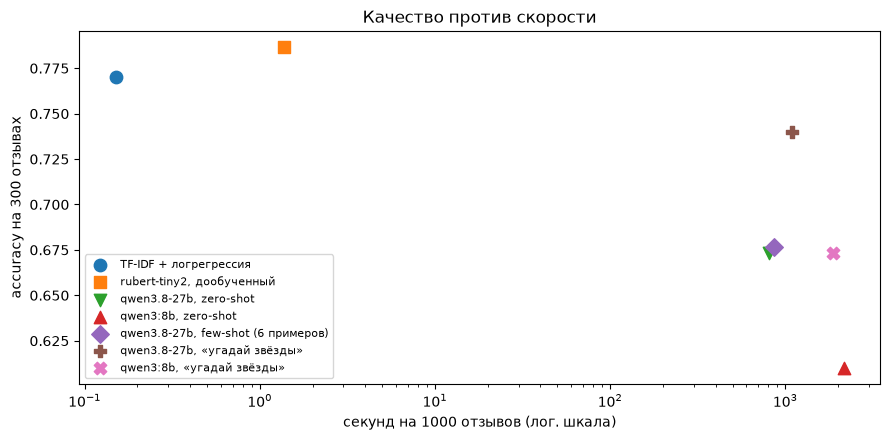

In [12]:
print("токенов на отзыв (вход / выход):")
for k, (inp, out) in tokens.items():
    print(f"  {k:18} {inp:6.0f} / {out:.0f}  →  на 1000 отзывов ≈ {inp * 1000 / 1e3:.0f} тыс. входных токенов")

fig, ax = plt.subplots(figsize=(9, 4.5))
for (name, row), marker in zip(table.iterrows(), "osv^DPX"):
    ax.scatter(row["секунд на 1000 отзывов"], row["accuracy (300)"], s=80, marker=marker, label=name)
ax.set_xscale("log")
ax.legend(fontsize=8, loc="lower left")
ax.set(xlabel="секунд на 1000 отзывов (лог. шкала)", ylabel="accuracy на 300 отзывах",
       title="Качество против скорости")
plt.tight_layout()
plt.show()

Выводы для этой задачи:

- **Качество.** Впереди дообученный rubert-tiny2 и TF-IDF. Лучшая LLM-постановка («угадай звёзды»
  на `main`) подбирается к ним, но не догоняет: на узкой задаче с большим размеченным набором
  специализированная модель сильна. На 300 отзывах погрешность около ±5 пунктов, поэтому разница
  между rubert-tiny2 и TF-IDF здесь не значима. На всём тесте они почти равны: 0,757 и 0,752.
- **Скорость и цена.** TF-IDF и маленький BERT обрабатывают тысячу отзывов за доли секунды. LLM — за
  минуты и сотни тысяч токенов. На миллионе отзывов в месяц разница измеряется днями работы GPU.
- **Данные.** LLM не нужна разметка: промпт работает в первый же день. Дообучению нужны десятки тысяч
  размеченных примеров, и они у нас были.
- **Шум в метках** ограничивает всех. Две очень разные модели на всём тесте упёрлись в 75–76%.
  Похоже, это потолок, который задают автоматические метки RuReviews, а не слабость моделей.

Типичная стратегия в продакшне: начать с LLM, чтобы получить работающий прототип и разметку без людей,
затем дообучить маленькую модель на накопленных данных, а LLM оставить для трудных случаев.

## ✅ Итоги

- `Trainer` + `DataCollatorWithPadding` — дообучение модели Hugging Face за десяток строк.
- JSON-схема заставляет LLM отвечать строго в заданном формате.
- Few-shot помогает не всегда. Переформулировать задачу так, как её решала разметка, дало больше.
- Выбор между дообучением и промптом — это компромисс качества, скорости, цены и наличия данных,
  и его решают замером на своей задаче.

✍️ **Упражнение:** `exercises/ex03_llm_classifier.py` — классификатор на LLM с фейковой моделью.